# 24a — baseline: the `experiment_6 trial_07` KDE model reproduced (series-24 reference)

**Series 24 — real-data accuracy.** New folder, new cycle. Goal (Anuar, 2026-09-26): the model must
optimise **correctly to the real data**, with **higher transmissions weighted more**, but ideally all 14
real experiments approximated. Process = the same as always: **one change per notebook → hypothesis →
test → verdict → the next notebook follows this one.**

**Starting point (decided from the whole-project survey):** the project's best *KDE* model is
**AG-HYPOPT `experiment_6` `trial_07`** — the exp5 winning schedule + the exp6 winner
(`sigma_weight 0.8649`, `h_f_scale 4.0`, `h_s_scale 3.6745`, `gamma_rel_cap 0.10736`), i.e. the series-21
μ mechanism (Anuar's `loglik_mean` reward, `sigma_prop` score, **no clip, no clamps**, init `0.5 × truth`).
It is the only family that can also carry a Fisher/CRB (exp8's `cvm_fwhm`/`w1_2d` are discrepancies).

**This notebook (24a) changes NOTHING** — it re-runs that model on all 14 real experiments under the
**frozen series-24 metric** (T-weighted objective, CAP 1.0, W_FLOOR 0.25) and becomes the reference every
later notebook is compared against. Series-23's `23a` recorded **W_obj = 0.0811 (all 14), 0.0675 (T ≥ 40)**;
this notebook must reproduce it.


## Hypothesis / prediction — 24a (baseline)

- **Change vs previous notebook:** none. 24a *is* the frozen reference (forked from `23a`).
- **Hypothesis:** the frozen `experiment_6 trial_07` model, re-run under the series-24 protocol, is the
  best available real-data **KDE** point estimate and reproduces the series-23 number.
- **Falsifiable prediction:** `W_obj(all14) ≈ 0.081` (± the chaos band), 0 divergences, γ ≤ 25 % rel-RMSE,
  and μ still the dominant channel (≈ 36 % rel-RMSE).
- **If falsified:** the series baseline is wrong → fix the reproduction before any one-change notebook.


## Panel (series-22 visual conventions)
- **FIG 1 (interactive, Plotly)** — per experiment: the **(mu, gamma) parameter path** (left) and the
  **generated (FWHM, sigma_fit) cloud at that step** (right) against the real data. Experiment dropdown +
  play button / slider over the iteration.
- **FIG 2 — the uncertainty report: μ on top, γ underneath** (one panel each, `hat/true` vs transmission
  with the CRB whiskers); the **hue is the laser power** (1nW | 3nW).
- **FIG 3** normalised trajectories `mu/mu_true`, `gamma/gamma_true` vs iteration (per power).
- **FIG 4** accuracy vs transmission (mu and gamma ratios, both powers, goal bands).

In [1]:
# ============================================================
# 23a — imports (repo bootstrap like the 22-series)
# ============================================================
import math, os, sys, time, json
from contextlib import nullcontext
import numpy as np
import torch
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

torch.set_default_dtype(torch.float32)
for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import fit_profile, fwhm_from_theta, nll
from src.samplers import draw_fixed_noise
from src.implicit import compute_fwhm_and_dgamma

import plotly
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
pio.templates.default = 'plotly_white'
pio.renderers.default = os.environ.get('PLOTLY_RENDERER', 'vscode')
print('Imports OK | plotly', plotly.__version__, '| repo', REPO_ROOT)


Imports OK | plotly 7.1.0 | repo /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../..


In [2]:
# ============================================================
# 23a — EXPERIMENTS (14 real; true values from Gregor's fits)
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393,   sigma_prop=2.576,  lam=2.232, gamma_true=8.5,  n_target=61),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372,  sigma_prop=3.445,  lam=2.122, gamma_true=8.5,  n_target=358),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316,  sigma_prop=4.141,  lam=2.286, gamma_true=8.5,  n_target=1138),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405,  sigma_prop=7.198,  lam=2.351, gamma_true=8.5,  n_target=2428),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374,  sigma_prop=9.851,  lam=2.593, gamma_true=8.5,  n_target=2424),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365,  sigma_prop=12.627, lam=2.758, gamma_true=8.5,  n_target=2487),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817,  sigma_prop=17.221, lam=2.636, gamma_true=8.5,  n_target=2455),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204,  sigma_prop=3.724,  lam=2.186, gamma_true=14.1, n_target=252),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476,  sigma_prop=5.639,  lam=2.158, gamma_true=14.1, n_target=1572),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279,  sigma_prop=8.319,  lam=2.264, gamma_true=14.1, n_target=2171),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892,  sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95,  lam=2.741, gamma_true=14.1, n_target=2541),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516),
]
POWERS = ['1nW', '3nW']
TRANS  = ['05', '10', '20', '40', '60', '80', '100']
print(len(EXPERIMENTS), 'experiments')


14 experiments


In [3]:
# ============================================================
# 24a CONFIG — FROZEN experiment_6 trial_07 model (the series-24 baseline)
# ============================================================
NB_ID      = '24a'
ONE_CHANGE = 'none - baseline: AG-HYPOPT experiment_6 trial_07 reproduced exactly (best KDE model)'
DO_FISHER  = False     # lean series-24 notebooks: point estimate only (Phase C switches this on)

CFG = dict(
    n_runs=100, n_iter=30,                       # series-21/exp5/6 protocol
    # FROZEN schedule = experiment_5 winning trial (trial_21)
    lr_mu=0.1669, mu_anneal=0.3455, lr_gamma=0.4716, gamma_anneal=0.4723,
    sigma_ref=10.0, clip=float('inf'),           # no gradient clipping (21i)
    # FROZEN experiment_6 winner (trial_07)
    sigma_weight=0.8648862719598797,             # sigma-channel damping
    gamma_rel_cap=0.10735617789825944,           # relative gamma trust region
    h_f_scale=4.0, h_s_scale=3.674548492934102,  # inflated Scott bandwidths
    h_s_min=0.05,
)
H_REF = 1.0            # z-form gamma-score reference (optimizer only)
SEED  = 42             # per-step noise seed base (deterministic)
REAL_CSV = os.path.join(REPO_ROOT, 'data', 'processed', 'fwhm_linewidths.csv')

# ---- Fisher knobs (used ONLY when DO_FISHER is True) ----
M_FINAL, FISHER_SEEDS, FISHER_BASE_SEED = 500, 5, 7000

OUT_JSON = os.path.join(REPO_ROOT, 'data', 'processed', f'{NB_ID}_history.json')

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    CFG['n_runs'], CFG['n_iter'] = 20, 4
    EXPERIMENTS = EXPERIMENTS[4:5]
    M_FINAL, FISHER_SEEDS = 40, 1
CACHED = (not SMOKE) and os.path.exists(OUT_JSON) and os.environ.get('NB_RECOMPUTE') != '1'
print(f'{NB_ID} | one change: {ONE_CHANGE}')
print(f'config: {CFG}')
print(f'M_FINAL={M_FINAL}, seeds={FISHER_SEEDS} | DO_FISHER={DO_FISHER} | SMOKE={SMOKE} | CACHED={CACHED}')


24a | one change: none - baseline: AG-HYPOPT experiment_6 trial_07 reproduced exactly (best KDE model)
config: {'n_runs': 100, 'n_iter': 30, 'lr_mu': 0.1669, 'mu_anneal': 0.3455, 'lr_gamma': 0.4716, 'gamma_anneal': 0.4723, 'sigma_ref': 10.0, 'clip': inf, 'sigma_weight': 0.8648862719598797, 'gamma_rel_cap': 0.10735617789825944, 'h_f_scale': 4.0, 'h_s_scale': 3.674548492934102, 'h_s_min': 0.05}
M_FINAL=500, seeds=5 | DO_FISHER=False | SMOKE=False | CACHED=False


In [4]:
# ============================================================
# 23a — helpers (verbatim from experiment_6/ag_hypopt.py, plus a gamma_scale switch)
# ============================================================
GAMMA_SCALE = True     # optimizer uses the z-form gamma-score; the Fisher sets this False

def _kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop, cfg):
    '''2-D KDE log-likelihood pieces + per-DATA-POINT scores (as exp5/6).'''
    sw = float(cfg.get('sigma_weight', 1.0))
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * sw * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = ((d_f * sim_df[None, :]) / h_f + sw * (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + sw * (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def _fit_fn(ph):  return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker(): torch.set_num_threads(1)
def _parallel_map(pool, tasks): return list(pool.map(_run_one, tasks, chunksize=8))

def _load_real_target(exp):
    '''Real measured target for `exp` (15-series convention): raw*1000 -> MHz, keep err/fwhm < 10.'''
    import pandas as pd
    power_nW = int(str(exp['power']).replace('nW', ''))
    trans = int(str(exp['name']).split('Trans')[-1])
    df = pd.read_csv(REAL_CSV)
    sub = df[(df['power_nW'] == power_nW) & (df['transmission'] == trans)]
    f = sub['fwhm'].to_numpy(dtype=float) * 1000.0
    e = sub['fit_error'].to_numpy(dtype=float) * 1000.0
    with np.errstate(invalid='ignore', divide='ignore'):
        ok = np.isfinite(f) & np.isfinite(e) & (f > 0)
        filt = ok & ((e / f) < 10.0)
    return (torch.tensor(f[filt], dtype=torch.float32), torch.tensor(e[filt], dtype=torch.float32))

def _bandwidths(target_f, target_s, h_f_scale, h_s_scale, h_s_min):
    '''Scott-from-target, scaled (FIXED w.r.t. mu,gamma -> a clean likelihood).'''
    scott = len(target_f) ** (-1.0 / 6.0)
    H_F = h_f_scale * float(target_f.std()) * scott
    H_S = max(h_s_scale * float(target_s.std()) * scott, h_s_min)
    return H_F, H_S

def _sims(pool, mu, sigma_prop, lam, gamma, n_runs, seed):
    rng = np.random.default_rng(seed)
    tasks, ns = [], []
    for _ in range(n_runs):
        u, b, n = draw_fixed_noise(mu, sigma_prop, lam, rng)
        tasks.append((gamma, u.numpy(), b.numpy())); ns.append(n)
    res = _parallel_map(pool, tasks)
    return (torch.tensor([r[0] for r in res], dtype=torch.float32),
            torch.tensor([r[1] for r in res], dtype=torch.float32),
            torch.tensor(ns, dtype=torch.float32),
            torch.tensor([r[2] for r in res], dtype=torch.float32),
            torch.tensor([r[3] for r in res], dtype=torch.float32))

def _fisher_at(pool, mu, gamma, sigma_prop, lam, target_f, target_s, H_F, H_S, cfg):
    '''Fisher of the KDE likelihood at (mu,gamma): per-scan J and the data-scaled J.
       Returns dict with sigma_mu/sigma_gamma under the per-scan normalisation and the
       dataset correction sigma/sqrt(N).'''
    global GAMMA_SCALE
    gs = GAMMA_SCALE; GAMMA_SCALE = False          # Fisher uses the RAW likelihood chain
    N = int(len(target_f))
    Js = []
    try:
        for s_i in range(FISHER_SEEDS):
            ft, si_t, nt, dg_t, ds_t = _sims(pool, mu, sigma_prop, lam, gamma, M_FINAL, FISHER_BASE_SEED + s_i)
            s_mu, s_gamma, _, _, _ = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                 target_f, target_s, H_F, H_S, mu, sigma_prop, cfg)
            s = torch.stack([s_mu, s_gamma], dim=1)
            Js.append(s.T @ s / N)                 # the EXISTING convention (per-scan)
    finally:
        GAMMA_SCALE = gs
    J_single = torch.stack(Js).mean(dim=0)
    inv_single = torch.linalg.inv(J_single + 1e-12 * torch.eye(2))
    inv_data = inv_single / N                      # dataset CRB = (N*J)^-1
    out = dict(N=N, J=J_single.tolist(),
               sig_mu_single=float(math.sqrt(inv_single[0, 0])),
               sig_g_single=float(math.sqrt(inv_single[1, 1])),
               corr_single=float(inv_single[0, 1] / math.sqrt(inv_single[0, 0] * inv_single[1, 1])),
               sig_mu_data=float(math.sqrt(inv_data[0, 0])),
               sig_g_data=float(math.sqrt(inv_data[1, 1])),
               corr_data=float(inv_data[0, 1] / math.sqrt(inv_data[0, 0] * inv_data[1, 1])))
    return out

print('helpers ready')


helpers ready


In [5]:
# ============================================================
# 23a — one experiment: the FROZEN optimisation (exp6 mechanism), recording the path
# ============================================================
def run_experiment(exp, cfg, pool):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true
    n_runs, n_iter = cfg['n_runs'], cfg['n_iter']
    lr_mu, lr_gamma = cfg['lr_mu'], cfg['lr_gamma']
    mu_anneal, gamma_anneal = cfg['mu_anneal'], cfg['gamma_anneal']
    gamma_rel_cap = cfg['gamma_rel_cap']; clip = cfg['clip']

    target_f, target_s = _load_real_target(exp)
    H_F, H_S = _bandwidths(target_f, target_s, cfg['h_f_scale'], cfg['h_s_scale'], cfg['h_s_min'])

    mu_val, gamma_val = float(mu_init), float(gamma_init)
    history, diverged, diverged_at = [], False, None
    t0 = time.time()
    for step in range(n_iter):
        ft, si_t, nt, dg_t, ds_t = _sims(pool, mu_val, sigma_prop, lam, gamma_val, n_runs, SEED + step)
        _, s_gamma, nll_val, w, W = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                target_f, target_s, H_F, H_S, mu_val, sigma_prop, cfg)
        r = torch.log(W.clamp_min(1e-30)).mean(dim=0)                 # Anuar's reward
        score = (nt - mu_val) / sigma_prop ** 2                       # sigma_prop score
        grad_mu = float(-(r - r.mean()) @ score)
        grad_gamma = float(-s_gamma.mean())
        mu_val -= lr_mu * (1.0 - mu_anneal * step / n_iter) * grad_mu
        dgamma = lr_gamma * (1.0 - gamma_anneal * step / n_iter) * grad_gamma
        lim = gamma_rel_cap * abs(gamma_val)
        dgamma = max(-lim, min(lim, dgamma))
        gamma_val -= dgamma
        history.append(dict(step=step, mu=float(mu_val), gamma=float(gamma_val), nll=float(nll_val),
                            grad_mu=grad_mu, grad_gamma=grad_gamma,
                            f=[round(float(x), 3) for x in ft], s=[round(float(x), 3) for x in si_t]))
        if not (0.2 <= mu_val <= 1500.0) or not (0.02 <= gamma_val <= 500.0):
            diverged = True; diverged_at = step; break
    return dict(exp=exp['name'], power=exp['power'], mu_true=mu_true, gamma_true=gamma_true,
                sigma_prop=sigma_prop, lam=lam, n_target=int(len(target_f)),
                mu_init=mu_init, gamma_init=gamma_init,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'],
                nll_final=history[-1]['nll'], history=history,
                target_f=[round(float(x), 3) for x in target_f], target_s=[round(float(x), 3) for x in target_s],
                H_F=H_F, H_S=H_S, diverged=diverged, diverged_at=diverged_at,
                t_elapsed=time.time() - t0)

print('run_experiment ready')


run_experiment ready


In [6]:
# ============================================================
# 23a — RUN: all 14 real experiments (the long cell)
# ============================================================
N_WORKERS = 4
CACHED = (not SMOKE) and os.path.exists(OUT_JSON) and os.environ.get('NB_RECOMPUTE') != '1'
RESULTS = []
if CACHED:
    RESULTS = json.load(open(OUT_JSON))['results']
    print(f'loaded {len(RESULTS)} experiments from {OUT_JSON} (set NB_RECOMPUTE=1 to recompute)')
t0 = time.time()
with (nullcontext() if CACHED else _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker)) as pool:
    for exp in EXPERIMENTS:
        if CACHED:
            continue
        r = run_experiment(exp, CFG, pool)
        RESULTS.append(r)
        print(f"  {r['exp']:13s} mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} | "
              f"gamma {r['gamma_true']:5.2f} -> {r['gamma_final']:6.2f} | NLL {r['nll_final']:.3f} | "
              f"{r['t_elapsed']/60:.1f} min{'  DIVERGED' if r['diverged'] else ''}", flush=True)
print(f'\ntotal {len(RESULTS)} experiments in {(time.time()-t0)/60:.1f} min')


  1nW Trans05   mu    9.39 ->    6.07 | gamma  8.50 ->   6.34 | NLL 0.251 | 1.3 min


  1nW Trans10   mu   12.37 ->   14.99 | gamma  8.50 ->   3.50 | NLL 0.281 | 1.3 min


  1nW Trans20   mu   17.32 ->   27.71 | gamma  8.50 ->   5.43 | NLL 0.647 | 1.3 min


  1nW Trans40   mu   38.41 ->   31.37 | gamma  8.50 ->   7.00 | NLL 0.806 | 1.3 min


  1nW Trans60   mu   61.37 ->   43.86 | gamma  8.50 ->   7.34 | NLL 0.909 | 1.3 min


...

  3nW Trans40   mu   84.89 ->   60.66 | gamma 14.10 ->  12.08 | NLL 0.782 | 1.4 min


  3nW Trans60   mu  103.20 ->   62.96 | gamma 14.10 ->  14.02 | NLL 0.698 | 1.4 min


  3nW Trans80   mu  137.54 ->   79.55 | gamma 14.10 ->  13.87 | NLL 0.715 | 1.4 min


  3nW Trans100  mu  175.71 ->   98.65 | gamma 14.10 ->  13.82 | NLL 0.612 | 1.4 min



total 14 experiments in 18.8 min


In [7]:
# ============================================================
# SERIES 24 — FROZEN PROTOCOL METRIC (identical in every series-24 notebook)
#   T-weighted objective (exp5/6 definition): per-cell rel-sq error capped at CAP,
#   weight w(T) = W_FLOOR + (1-W_FLOOR)*T/100.  Lower = better.
# ============================================================
CAP, W_FLOOR = 1.0, 0.25
def tw_objective(results, Ts=None):
    rows = []
    for r in results:
        T = int(str(r['exp']).split('Trans')[-1])
        if Ts is not None and T not in Ts:
            continue
        em = min(((r['mu_final'] - r['mu_true']) / r['mu_true']) ** 2, CAP)
        eg = min(((r['gamma_final'] - r['gamma_true']) / r['gamma_true']) ** 2, CAP)
        w  = W_FLOOR + (1.0 - W_FLOOR) * T / 100.0
        rows.append((w, em, eg))
    if not rows:
        return float('nan')
    wts  = np.array([x[0] for x in rows] * 2)
    errs = np.array([x[1] for x in rows] + [x[2] for x in rows])
    return float((wts * errs).sum() / wts.sum())

OBJ_ALL = tw_objective(RESULTS)
OBJ_HI  = tw_objective(RESULTS, Ts={40, 60, 80, 100})
OBJ_LO  = tw_objective(RESULTS, Ts={5, 10, 20})
MU_RMSE = float(np.sqrt(np.mean([((r['mu_final'] - r['mu_true']) / r['mu_true']) ** 2 for r in RESULTS]))) * 100
G_RMSE  = float(np.sqrt(np.mean([((r['gamma_final'] - r['gamma_true']) / r['gamma_true']) ** 2 for r in RESULTS]))) * 100
N_DIV   = int(sum(bool(r['diverged']) for r in RESULTS))
print('=' * 74)
print(f'FROZEN METRIC ({NB_ID})   W_obj(all14) = {OBJ_ALL:.4f} | T>=40 {OBJ_HI:.4f} | T<=20 {OBJ_LO:.4f}')
print(f'                          mu rel-RMSE {MU_RMSE:.1f}% | gamma rel-RMSE {G_RMSE:.1f}% | diverged {N_DIV}/14')
print('=' * 74)
print(f"{'exp':14s}{'mu_true':>9s}{'mu_fit':>9s}{'mu/true':>9s} | {'gam_true':>9s}{'gam_fit':>9s}{'gam/true':>9s}")
for r in RESULTS:
    print(f"{r['exp']:14s}{r['mu_true']:9.2f}{r['mu_final']:9.2f}{r['mu_final']/r['mu_true']:9.3f} | "
          f"{r['gamma_true']:9.2f}{r['gamma_final']:9.2f}{r['gamma_final']/r['gamma_true']:9.3f}"
          f"{'   DIV' if r['diverged'] else ''}")
print()
print(f"{'T':>6}{'mu(1nW)':>10}{'mu(3nW)':>10}{'gam(1nW)':>11}{'gam(3nW)':>11}")
for T in sorted({int(str(r['exp']).split('Trans')[-1]) for r in RESULTS}):
    vals = []
    for p in POWERS:
        rs = [r for r in RESULTS if r['power'] == p and int(str(r['exp']).split('Trans')[-1]) == T]
        vals.append(round(rs[0]['mu_final'] / rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in POWERS:
        rs = [r for r in RESULTS if r['power'] == p and int(str(r['exp']).split('Trans')[-1]) == T]
        vals.append(round(rs[0]['gamma_final'] / rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{T:>6}{vals[0]:>10}{vals[1]:>10}{vals[2]:>11}{vals[3]:>11}")


FROZEN METRIC (24a)   W_obj(all14) = 0.0811 | T>=40 0.0675 | T<=20 0.1228
                          mu rel-RMSE 33.2% | gamma rel-RMSE 26.1% | diverged 0/14
exp             mu_true   mu_fit  mu/true |  gam_true  gam_fit gam/true
1nW Trans05        9.39     6.07    0.646 |      8.50     6.34    0.746
1nW Trans10       12.37    14.99    1.212 |      8.50     3.50    0.411
1nW Trans20       17.32    27.71    1.600 |      8.50     5.43    0.639
1nW Trans40       38.41    31.37    0.817 |      8.50     7.00    0.824
1nW Trans60       61.37    43.86    0.715 |      8.50     7.34    0.864
1nW Trans80       79.36    47.30    0.596 |      8.50     7.66    0.901
1nW Trans100      70.82    51.68    0.730 |      8.50     7.93    0.933
3nW Trans05       13.20    16.02    1.213 |     14.10     8.61    0.610
3nW Trans10       24.48    26.69    1.090 |     14.10     8.74    0.620
3nW Trans20       34.28    32.54    0.949 |     14.10    11.68    0.829
3nW Trans40       84.89    60.66    0.715 |     14.

In [8]:
# ============================================================
# SERIES 24 — FISHER at each optimum (ONLY when DO_FISHER):
#   (A) per-scan normalisation J = sum/N   -> sigma_*_single   (the historic convention)
#   (B) dataset correction  sig/sqrt(N)    -> sigma_*_data     (the whole experiment)
# ============================================================
t0 = time.time()
if not DO_FISHER:
    print('DO_FISHER=False - Fisher block skipped (series-24 point-estimate notebook)')
elif CACHED and all('fisher_frozen' in r for r in RESULTS):
    print('fisher block: cached')
else:
    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
        for r in RESULTS:
            exp = next(e for e in EXPERIMENTS if e['name'] == r['exp'])
            tf = torch.tensor(r['target_f'], dtype=torch.float32)
            ts = torch.tensor(r['target_s'], dtype=torch.float32)
            r['fisher_frozen'] = _fisher_at(pool, r['mu_final'], r['gamma_final'], r['sigma_prop'],
                                            r['lam'], tf, ts, r['H_F'], r['H_S'], CFG)
            print(f"  {r['exp']:13s} N={r['n_target']:5d} | sig_mu per-scan "
                  f"{r['fisher_frozen']['sig_mu_single']:8.1f} -> dataset {r['fisher_frozen']['sig_mu_data']:7.2f}",
                  flush=True)
    print(f'fisher block: {(time.time()-t0)/60:.1f} min')


DO_FISHER=False - Fisher block skipped (series-24 point-estimate notebook)


In [9]:
# ============================================================
# SERIES 24 — per-experiment summary table [+ Fisher coverage when DO_FISHER]
# ============================================================
TABLE = []
for r in RESULTS:
    dmu = abs(r['mu_final'] - r['mu_true']); dg = abs(r['gamma_final'] - r['gamma_true'])
    row = dict(exp=r['exp'], n=r['n_target'], mu_true=r['mu_true'], mu=r['mu_final'],
               gamma_true=r['gamma_true'], gamma=r['gamma_final'], dmu=dmu, dgamma=dg,
               ratio_mu=r['mu_final'] / r['mu_true'], ratio_gamma=r['gamma_final'] / r['gamma_true'])
    fr = r.get('fisher_frozen')
    if fr and fr.get('sig_mu_single'):
        row.update(sig_mu_single=fr['sig_mu_single'], sig_mu_data=fr['sig_mu_data'],
                   sig_g_single=fr['sig_g_single'], sig_g_data=fr['sig_g_data'], corr=fr.get('corr_data'),
                   dmu_sigma_single=dmu / fr['sig_mu_single'], dmu_sigma_data=dmu / fr['sig_mu_data'],
                   dg_sigma_single=dg / fr['sig_g_single'], dg_sigma_data=dg / fr['sig_g_data'])
    TABLE.append(row)

if DO_FISHER:
    cov = lambda k, thr=2.0: sum(1 for t in TABLE if t.get(k, 1e30) <= thr)
    print('coverage within 2 sigma (mu):  per-scan %d/14 | dataset %d/14'
          % (cov('dmu_sigma_single'), cov('dmu_sigma_data')))
    print('coverage within 1 sigma (mu):  per-scan %d/14 | dataset %d/14'
          % (cov('dmu_sigma_single', 1), cov('dmu_sigma_data', 1)))
    print('gamma: median |dgamma|/sigma  per-scan %.2f | dataset %.2f'
          % (np.median([t['dg_sigma_single'] for t in TABLE]),
             np.median([t['dg_sigma_data'] for t in TABLE])))
else:
    print('DO_FISHER=False - coverage table skipped')


DO_FISHER=False - coverage table skipped


In [10]:
# ============================================================
# SERIES 24 — save companion run data (paths + per-step clouds [+ Fisher when DO_FISHER])
# ============================================================
if SMOKE or CACHED:
    print('smoke/cached: not re-saving')
else:
    payload = dict(notebook=NB_ID, one_change=ONE_CHANGE, config=CFG, DO_FISHER=DO_FISHER,
                   objective=dict(all14=OBJ_ALL, hiT=OBJ_HI, loT=OBJ_LO,
                                  mu_rel_rmse=MU_RMSE, gamma_rel_rmse=G_RMSE, n_diverged=N_DIV),
                   results=RESULTS)
    json.dump(payload, open(OUT_JSON, 'w'))
    print('saved', OUT_JSON, f'({os.path.getsize(OUT_JSON)/1e6:.2f} MB)')


saved /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../data/processed/24a_history.json (1.09 MB)


In [11]:
# ============================================================
# 23a — FIG 1: (mu,gamma) path  |  generated (FWHM, sigma_fit) cloud vs real data
#   EXACTLY the 22a design: one interactive figure per power (1nW, 3nW), experiment dropdown
#   + play button + slider over the steps. Frames rewrite a PREFIX of the trace list; the
#   per-experiment static traces (init / truth / real data) are written once, on each
#   experiment's step-0 frame.
# ============================================================
N_ITER = CFG['n_iter']
CONFIG_PLOT = {'scrollZoom': True, 'displaylogo': False, 'responsive': True}
for r in RESULTS:                                  # 22a field names
    r['T'] = int(str(r['exp']).split('Trans')[-1])
    for fr in r['history']:
        fr['cloud_f'] = fr['f']; fr['cloud_s'] = fr['s']

def _grid_range(f, s, pct=(2, 98), pad=0.12):
    lo_f, hi_f = np.percentile(f, pct); lo_s, hi_s = np.percentile(s, pct)
    df, ds = max(hi_f - lo_f, 1e-6), max(hi_s - lo_s, 1e-6)
    return (lo_f - pad*df, hi_f + pad*df), (lo_s - pad*ds, hi_s + pad*ds)

def _density(cf, cs, xr, yr, nx=36, ny=36, smooth=1.2):
    H, xe, ye = np.histogram2d(cf, cs, bins=[nx, ny], range=[xr, yr])
    Z = gaussian_filter(H.T, smooth)
    Z = Z / max(Z.max(), 1e-12)
    return 0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:]), np.round(Z*100).astype(int)   # int % -> compact

def build_power_figure(results, power):
    # 22a's builder, verbatim (only the history field names are adapted).
    rs = sorted([r for r in results if r['power'] == power], key=lambda r: r['T'])
    if not rs:
        print(f'no {power} experiments -> figure skipped'); return None

    grids, pranges = {}, {}
    for r in rs:
        cf = np.concatenate([fr['cloud_f'] for fr in r['history']])
        cs = np.concatenate([fr['cloud_s'] for fr in r['history']])
        grids[r['exp']] = _grid_range(np.concatenate([cf, r['target_f']]),
                                      np.concatenate([cs, r['target_s']]))
        pmus = [fr['mu'] for fr in r['history']] + [r['mu_true'], r['mu_init']]
        pgam = [fr['gamma'] for fr in r['history']] + [r['gamma_true'], r['gamma_init']]
        pranges[r['exp']] = ((0, max(pmus)*1.05), (0, max(pgam)*1.05))

    fig = make_subplots(rows=1, cols=2, column_widths=[0.40, 0.60], horizontal_spacing=0.10,
                        subplot_titles=['(μ, γ) path', '(FWHM, σ_fit)  simulated cloud  vs  real data'])
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#1d3557', width=2), name='path'), 1, 1)          # 0
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=12, symbol='x'), name='current'), 1, 1)  # 1
    fig.add_trace(go.Contour(x=[0, 1], y=[0, 1], z=[[0, 0], [0, 0]], colorscale='Blues', showscale=False,
                             contours=dict(showlines=False), opacity=0.85, name='sim density'), 1, 2)                    # 2
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#457b9d', size=4, opacity=0.45),
                             name='sim draws'), 1, 2)                                                                    # 3
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#2a9d8f', size=11, symbol='circle-open',
                             line=dict(width=2)), name='init 0.5x'), 1, 1)                                               # 4
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#000000', size=13, symbol='cross'),
                             name='truth'), 1, 1)                                                                        # 5
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=5, opacity=0.85,
                             symbol='diamond'), name='real data'), 1, 2)                                                 # 6

    frames = []
    for r in rs:
        xr, yr = grids[r['exp']]; (px0, px1), (py0, py1) = pranges[r['exp']]
        for fr in r['history']:
            k = fr['step']
            px = [h['mu'] for h in r['history'][:k+1]]
            py = [h['gamma'] for h in r['history'][:k+1]]
            xc, yc, Z = _density(fr['cloud_f'], fr['cloud_s'], xr, yr)
            data = [go.Scatter(x=px, y=py),
                    go.Scatter(x=[px[-1]], y=[py[-1]]),
                    go.Contour(x=xc, y=yc, z=Z),
                    go.Scatter(x=fr['cloud_f'], y=fr['cloud_s'])]
            if k == 0:      # per-experiment static context, written once per experiment
                data += [go.Scatter(x=[r['mu_init']], y=[r['gamma_init']]),
                         go.Scatter(x=[r['mu_true']], y=[r['gamma_true']]),
                         go.Scatter(x=r['target_f'], y=r['target_s'])]
            frames.append(go.Frame(name=f"{r['exp']}|{k}", data=data, layout=go.Layout(
                title_text=f"{r['exp']}  —  step {k}/{N_ITER}   (μ x{px[-1]/r['mu_true']:.2f}, γ x{py[-1]/r['gamma_true']:.2f})",
                xaxis=dict(range=[px0, px1], title='μ (photons)'),
                yaxis=dict(range=[py0, py1], title='γ (MHz)'),
                xaxis2=dict(range=[xr[0], xr[1]], title='FWHM (MHz)'),
                yaxis2=dict(range=[yr[0], yr[1]], title='σ_fit (MHz)'),
            )))
    fig.frames = frames

    for tr, d in zip(fig.data, frames[0].data):     # step-0 state on the base traces
        for prop in ('x', 'y', 'z'):
            val = getattr(d, prop, None)
            if val is not None:
                setattr(tr, prop, val)

    exps = [r['exp'] for r in rs]
    play  = dict(label='▶ play', method='animate',
                 args=[None, dict(frame=dict(duration=350, redraw=True), fromcurrent=True, transition=dict(duration=0))])
    pause = dict(label='❚❚ pause', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    dropdown = [dict(label=e, method='animate',
                     args=[[f'{e}|0'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
                for e in exps]
    steps = [dict(method='animate', label=fr.name.split('|')[1],
                  args=[[fr.name], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
             for fr in frames]          # built from the ACTUAL frames (robust to the frame count)
    fig.update_layout(
        height=620, margin=dict(t=120, b=40),
        updatemenus=[
            dict(type='buttons', direction='left', x=0.0, y=1.18, xanchor='left', buttons=[play, pause]),
            dict(type='dropdown', direction='down', x=1.0, y=1.18, xanchor='right',
                 showactive=True, buttons=dropdown, active=0),
        ],
        sliders=[dict(active=0, x=0.0, len=1.0, y=-0.06, currentvalue=dict(prefix=''), steps=steps)],
    )
    return fig

print('build_power_figure ready')


build_power_figure ready


In [12]:
# FIG 1a — 1nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_1nW = build_power_figure(RESULTS, '1nW')
if fig_1nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '24_realdata_accuracy', '24a-fig1a-1nW-paths-clouds.html')
    fig_1nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_1nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../notebooks/24_realdata_accuracy/24a-fig1a-1nW-paths-clouds.html (1.3 MB)


In [13]:
# FIG 1b — 3nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_3nW = build_power_figure(RESULTS, '3nW')
if fig_3nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '24_realdata_accuracy', '24a-fig1b-3nW-paths-clouds.html')
    fig_3nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_3nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../notebooks/24_realdata_accuracy/24a-fig1b-3nW-paths-clouds.html (1.3 MB)


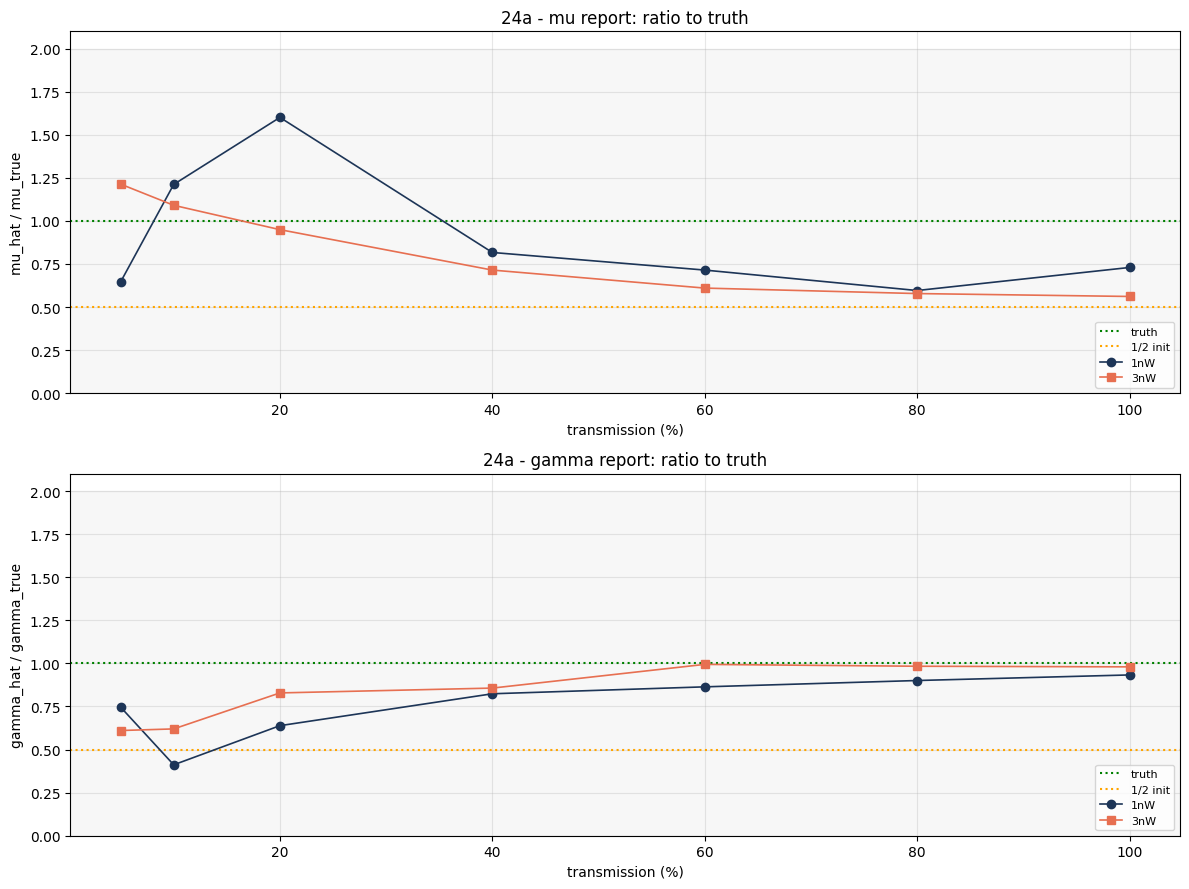

In [14]:
# ============================================================
# FIG 2 — the μ report (top) and the γ report (bottom): ratio to truth ± the Fisher CRB whisker.
#   22a's style; ONE panel per parameter, with the hue = laser power (1nW | 3nW).
#   Whisker = the dataset CRB (B): truth-inside = honesty.
# ============================================================
def _trow(power):
    return sorted([t for t in TABLE if t['exp'].startswith(power)],
                  key=lambda t: int(t['exp'].split('Trans')[-1]))

COL = {'1nW': '#1d3557', '3nW': '#e76f51'}
MK  = {'1nW': 'o-', '3nW': 's-'}
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, key in zip(axes, ['mu', 'gamma']):
    for power in POWERS:
        ts = _trow(power)
        xs = [int(t['exp'].split('Trans')[-1]) for t in ts]
        if key == 'mu':
            ys  = [t['mu'] / t['mu_true'] for t in ts]
            err = [t['sig_mu_data'] / t['mu_true'] for t in ts] if DO_FISHER else None
        else:
            ys  = [t['gamma'] / t['gamma_true'] for t in ts]
            err = [t['sig_g_data'] / t['gamma_true'] for t in ts] if DO_FISHER else None
        ax.errorbar(xs, ys, yerr=err, fmt=MK[power], color=COL[power], capsize=4, ms=6, lw=1.2,
                    label=(f'{power}   (whisker = Fisher sigma_{key})' if DO_FISHER else power))
    ax.axhline(1.0, color='g', ls=':', label='truth')
    ax.axhline(0.5, color='orange', ls=':', label='1/2 init')
    ax.axhspan(0.0, 2.0, color='gray', alpha=0.06)
    ax.set_xlabel('transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true')
    ax.set_ylim(0, 2.1); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f"{NB_ID} - {key} report: ratio to truth" + (" with Fisher sigma whiskers (dataset CRB)" if DO_FISHER else ""))
fig.tight_layout(); plt.show()


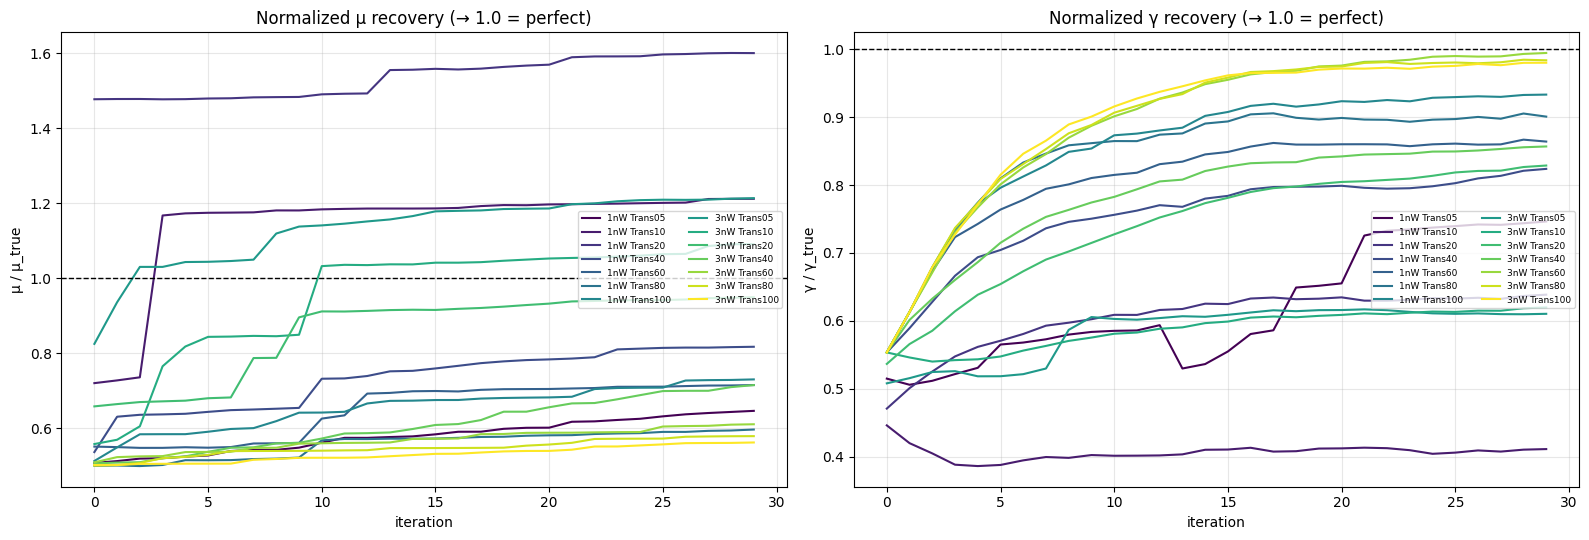

In [15]:
# ============================================================
# FIG 3 — normalized trajectories (μ/μ_true, γ/γ_true vs iteration); starts AT the 0.5x init
#   (22a verbatim)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(RESULTS)))
for r, c in zip(RESULTS, colors):
    st = [h['step'] for h in r['history']]
    axes[0].plot(st, [h['mu']    / r['mu_true']    for h in r['history']], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(st, [h['gamma'] / r['gamma_true'] for h in r['history']], color=c, lw=1.5, label=r['exp'])
for ax, yl in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1); ax.set_xlabel('iteration'); ax.set_ylabel(yl); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout(); plt.show()


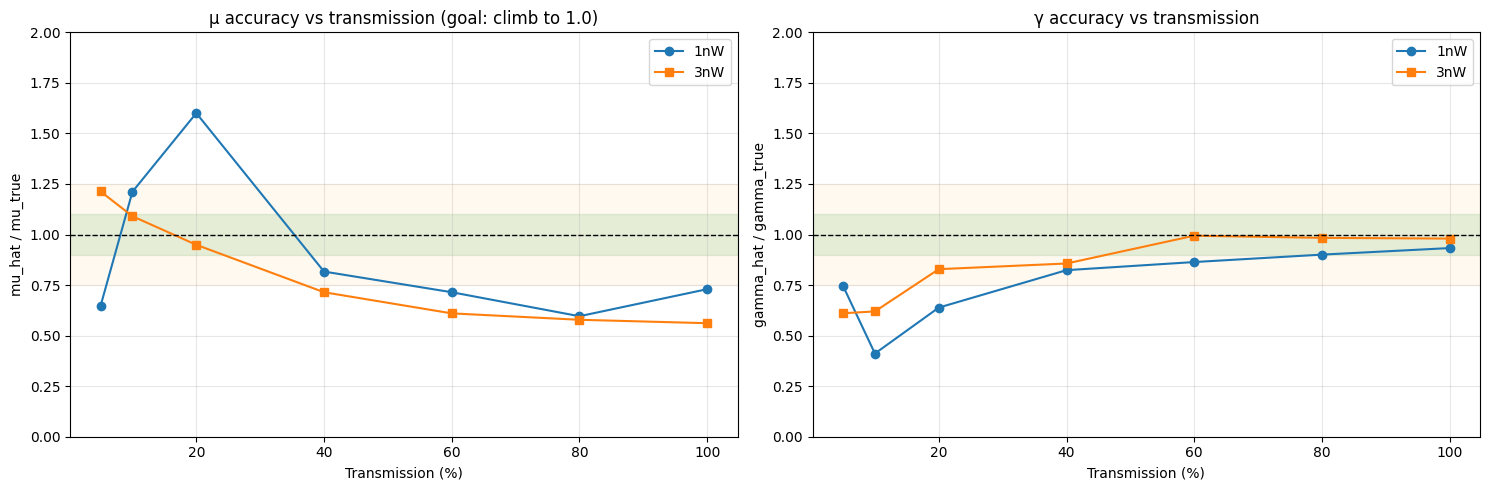

graded-goal check (ratio by transmission):
    T   mu(1nW)   mu(3nW)    g(1nW)    g(3nW)
    5     0.646     1.213     0.746      0.61
   10     1.212      1.09     0.411      0.62
   20       1.6     0.949     0.639     0.829
   40     0.817     0.715     0.824     0.857
   60     0.715      0.61     0.864     0.994
   80     0.596     0.578     0.901     0.983
  100      0.73     0.561     0.933      0.98


In [16]:
# ============================================================
# FIG 4 — accuracy vs transmission (goal: ratios climb toward 1.0 with T)   (22a verbatim)
# ============================================================
pows = ['1nW', '3nW']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = sorted([r for r in RESULTS if r['power'] == p], key=lambda z: z['T'])
        if not rs: continue
        xs = [r['T'] for r in rs]
        ys = [(r['mu_final']/r['mu_true']) if key == 'mu' else (r['gamma_final']/r['gamma_true']) for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.axhspan(0.9, 1.1, color='green', alpha=0.10); ax.axhspan(0.75, 1.25, color='orange', alpha=0.06)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true'); ax.set_ylim(0, 2.0)
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('μ accuracy vs transmission (goal: climb to 1.0)')
axes[1].set_title('γ accuracy vs transmission')
plt.tight_layout(); plt.show()

print('graded-goal check (ratio by transmission):')
print(f"{'T':>5} {'mu(1nW)':>9} {'mu(3nW)':>9} {'g(1nW)':>9} {'g(3nW)':>9}")
for T in sorted({r['T'] for r in RESULTS}):
    row = [T]
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['mu_final']/rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['gamma_final']/rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{row[0]:>5} {row[1]:>9} {row[2]:>9} {row[3]:>9} {row[4]:>9}")


In [17]:
if not DO_FISHER:
    print('DO_FISHER=False - FIG5 (Fisher ellipses) skipped')
else:
    # ============================================================
    # FIG 5 — FISHER ELLIPSES (1σ) in (μ, γ) at the fitted point
    #   21c's FIG 10, laid out as 2 columns (1nW | 3nW) × 7 rows (Trans05…Trans100).
    #   The ellipse is the dataset CRB (B). Variant A (per-scan) is a factor √N larger -> off-panel.
    # ============================================================
    from matplotlib.patches import Ellipse
    fig, axes = plt.subplots(7, 2, figsize=(12, 26))
    for ci, power in enumerate(POWERS):
        ts = _trow(power)
        for ri, t in enumerate(ts):
            ax = axes[ri][ci]
            sm, sg, corr = t['sig_mu_data'], t['sig_g_data'], t['corr']
            degenerate = sg < 1e-6                       # σ_γ → 0: the low-count Fisher degeneracy
            if not degenerate:
                cov = np.array([[sm**2, corr*sm*sg], [corr*sm*sg, sg**2]])
                lam_, vec = np.linalg.eigh(cov)
                ang = np.degrees(np.arctan2(vec[1, -1], vec[0, -1]))
                ax.add_patch(Ellipse((t['mu'], t['gamma']), 2*np.sqrt(lam_[0]), 2*np.sqrt(lam_[1]),
                                     angle=ang, facecolor='#457b9d', edgecolor='k', alpha=0.35, lw=0.8,
                                     label='Fisher CRB (1σ, dataset)'))
            ax.plot(t['mu'], t['gamma'], 'b.', ms=9, label='fit')
            ax.plot(t['mu_true'], t['gamma_true'], 'g*', ms=16, label='truth')
            dg_txt = 'σγ→0 (degenerate)' if degenerate else f"Δγ/σ={t['dg_sigma_data']:.1f}"
            ax.set_title(f"{t['exp']}  |  Δμ/σ={t['dmu_sigma_data']:.1f}   {dg_txt}", fontsize=8)
            ax.set_xlabel('μ (photons)'); ax.set_ylabel('γ (MHz)'); ax.grid(alpha=0.3); ax.legend(fontsize=6)
    plt.suptitle('23a — Fisher CRB ellipses (1σ, dataset) at the fitted point', fontsize=13)
    plt.tight_layout(); plt.show()

DO_FISHER=False - FIG5 (Fisher ellipses) skipped


## Verdict — the series-24 baseline is reproduced exactly: `W_obj(all14) = 0.0811` (0 divergences)

| metric | 24a (this notebook) | series-23 `23a` (same model) |
|---|---|---|
| **W_obj(all14)** | **0.0811** | 0.0811 |
| W_obj(T ≥ 40) | **0.0675** | 0.0675 |
| W_obj(T ≤ 20) | 0.1228 | — |
| μ rel-RMSE (all 14) | 33.2 % | (35.9 % = the *8-exp benchmark* subset — consistent) |
| γ rel-RMSE (all 14) | 26.1 % | (22.3 % benchmark) |
| diverged | **0/14** | 0/14 |

**Prediction: HIT.** The frozen `experiment_6 trial_07` model reproduces its series-23 number to 4 decimals
under the series-24 protocol. The baseline is therefore trustworthy and every later one-change notebook is
compared against **0.0811 / 0.0675 / 0.1228**.

**(a) Where the error is.** μ is still the dominant channel and it is **directional, not random**:
- **Low T overshoots**: 1nW T20 = ×1.60, 1nW T10 = ×1.21, 3nW T05 = ×1.21 (too much travel).
- **High T undershoots**: 3nW T100 = ×0.56, 1nW T80 = ×0.60, 3nW T60 = ×0.61, 1nW T60 = ×0.72 (−30…−44 %).
So the two regimes fail in **opposite directions** — the single global `lr_mu` anneal cannot serve both
(the mechanism `23e` diagnosed; this is the target of Phase A).
**(b) γ** climbs monotonically toward truth with T (0.61 → 0.98 at 3nW; 0.75 → 0.93 at 1nW) — the FM#6
1nW low-T deficit is the residual (1nW T10 γ = ×0.41).
**FM tags:** FM#8 (σ-channel μ attractor, high T) + FM#6 (low-T γ) + the step-budget effect (low-T overshoot).
**Next:** Phase A — **A2 (24b)**, the truth-free travel normalisation `Δμ = (μ_init/N_ITER)·grad/⟨|grad|⟩`.


## Notes / caveats

- **Chaos band.** The objective is chaotically sensitive (~±0.01 for <1e-3 knob changes; integer photon
  rounding). Treat ≤0.005 differences as noise; repeat a winning config ≥2× before believing it.
- **Truth-free rule.** Every knob derived from data must come from the *target cloud* or the *sim cloud* —
  never from `mu_true`/`gamma_true`. (The protocol init `0.5 × truth` is the single documented exception
  and is a property of the protocol, not a tuned knob.)
- **One change per notebook**, stated in the markdown cell above the config; keep the rest byte-identical
  by **forking the previous notebook** (`cp 24x.ipynb 24y.ipynb`).
- Figures render inline (no `savefig`); FIG1 is exported to HTML for the browser. Run **in place**
  (`papermill 24x.ipynb 24x.ipynb`), never an `-executed` copy.
- Append the log row in `SERIES_STATE.md` §7 and commit+push after every notebook.
